<a href="https://colab.research.google.com/github/abdulazoor/northstar-databases-analytics/blob/main/notebooks/01_SQL_R_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================
# NORTHSTAR ANALYTICS PROJECT
# SQL IN R ANALYSIS
# ==========================================

# Install required packages
install.packages("sqldf")
install.packages("dplyr")
install.packages("ggplot2")
install.packages("readr")
install.packages("lubridate")
install.packages("stringr")
install.packages("tidyr")

# Load libraries
library(sqldf)
library(dplyr)
library(ggplot2)
library(readr)
library(lubridate)
library(stringr)
library(tidyr)

cat("Libraries loaded successfully.\n")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff,

Libraries loaded successfully.


In [ ]:
# ==========================================
# IMPORT DATASETS
# ==========================================

customers <- read_csv("customers.csv")
orders <- read_csv("orders.csv")
deliveries <- read_csv("deliveries.csv")
drivers <- read_csv("drivers.csv")
vehicles <- read_csv("vehicles.csv")
complaints <- read_csv("complaints.csv")
incidents <- read_csv("incidents.csv")
app_events <- read_csv("app_events.csv")
hubs <- read_csv("hubs.csv")
data_dictionary <- read_csv("data_dictionary.csv")

cat("Datasets imported successfully.\n")

Rows: 650 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (5): customer_id, home_zone, customer_type, preferred_channel, account_...
dbl  (3): age, loyalty_score, app_engagement_score
dttm (1): signup_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1250 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (7): order_id, customer_id, service_type, pickup_zone, dropoff_zone, pr...
dbl  (3): promised_window_hours, order_value, special_handling_flag
dttm (1): order_created_at

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 950 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (6)

Datasets imported successfully.


In [ ]:
# ==========================================
# DATASET STRUCTURE ANALYSIS
# ==========================================

str(customers)
str(orders)
str(deliveries)
str(drivers)
str(vehicles)
str(complaints)
str(incidents)
str(app_events)
str(hubs)

# Row counts
cat("Customers:", nrow(customers), "\n")
cat("Orders:", nrow(orders), "\n")
cat("Deliveries:", nrow(deliveries), "\n")
cat("Drivers:", nrow(drivers), "\n")
cat("Vehicles:", nrow(vehicles), "\n")
cat("Complaints:", nrow(complaints), "\n")
cat("Incidents:", nrow(incidents), "\n")
cat("App Events:", nrow(app_events), "\n")
cat("Hubs:", nrow(hubs), "\n")

spc_tbl_ [650 × 9] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ customer_id         : chr [1:650] "C0001" "C0002" "C0003" "C0004" ...
 $ age                 : num [1:650] 26 61 66 75 26 41 54 70 34 23 ...
 $ home_zone           : chr [1:650] "North" "AIRPORT" "East" "CENTRAL" ...
 $ customer_type       : chr [1:650] "SME" "Consumer" "Consumer" "Consumer" ...
 $ signup_date         : POSIXct[1:650], format: "2024-11-27 04:25:00" "2025-10-28 01:04:00" ...
 $ loyalty_score       : num [1:650] 44.9 55.4 75.9 32.5 55.9 39.9 36.1 84.6 62.6 87.2 ...
 $ app_engagement_score: num [1:650] 69.2 66.6 33.8 33 100 43.3 39 65.2 40.8 48.6 ...
 $ preferred_channel   : chr [1:650] "App" "App" NA "App" ...
 $ account_status      : chr [1:650] "Active" "Active" "Active" "Active" ...
 - attr(*, "spec")=
  .. cols(
  ..   customer_id = col_character(),
  ..   age = col_double(),
  ..   home_zone = col_character(),
  ..   customer_type = col_character(),
  ..   signup_date = col_datetime(format = ""),
  ..   l

In [ ]:
# ==========================================
# MISSING VALUE ANALYSIS
# ==========================================

missing_summary <- function(df) {
  sapply(df, function(x) sum(is.na(x)))
}

missing_summary(customers)
missing_summary(orders)
missing_summary(deliveries)
missing_summary(drivers)
missing_summary(vehicles)
missing_summary(complaints)
missing_summary(incidents)
missing_summary(app_events)
missing_summary(hubs)

customer_id                  age            home_zone 
                   0                    0                    0 
       customer_type          signup_date        loyalty_score 
                   0                    0                   20 
app_engagement_score    preferred_channel       account_status 
                   0                   13                    0

order_id           customer_id          service_type 
                    0                     0                     0 
     order_created_at promised_window_hours           pickup_zone 
                    0                     0                     0 
         dropoff_zone        priority_level           order_value 
                    0                     0                     0 
      booking_channel special_handling_flag 
                   25                     0

delivery_id                      order_id 
                            0                             0 
                    driver_id                    vehicle_id 
                            0                             0 
                       hub_id                 dispatch_time 
                            0                             0 
        delivery_completed_at               delivery_status 
                           19                             0 
            route_distance_km   manual_route_override_count 
                            0                             0 
  proof_of_completion_missing customer_rating_post_delivery 
                            0                            14 
          fuel_or_charge_cost 
                            0

driver_id        base_zone  employment_type years_experience 
               0                0                0                0 
  training_score    driver_rating shift_preference      active_flag 
               7                0                0                0

vehicle_id       vehicle_type      assigned_zone    commission_date 
                 0                  0                  0                  0 
battery_health_pct        odometer_km maintenance_status telematics_version 
                 4                  0                  0                  0

complaint_id         customer_id            order_id      complaint_type 
                  0                   0                   0                   0 
            channel            severity          created_at              status 
                  0                   0                   0                   0 
    resolution_days compensation_amount 
                  0                  16

incident_id       delivery_id     incident_type       reported_at 
                0                 0                 0                 0 
         severity resolution_status    resolved_hours 
                0                 0                17

event_id     customer_id        order_id event_timestamp      event_type 
              0               0             144               0               0 
     session_id     device_type    zone_context  api_latency_ms    success_flag 
              0               0               0               0               0

hub_id       hub_name           zone       hub_type capacity_score 
             0              0              0              0              0

In [ ]:
# ==========================================
# DATA CLEANING
# ==========================================

# Standardize delivery statuses
deliveries$delivery_status <- str_trim(deliveries$delivery_status)

deliveries$delivery_status[
  deliveries$delivery_status %in%
    c("Delayed", "Delay", "Late", "Delivery Delayed")
] <- "Delayed"

deliveries$delivery_status[
  deliveries$delivery_status %in%
    c("Failed", "Failure")
] <- "Failed"

deliveries$delivery_status[
  deliveries$delivery_status %in%
    c("Completed", "Complete", "Success")
] <- "Completed"

# Fill missing customer ratings
median_rating <- median(
  deliveries$customer_rating_post_delivery,
  na.rm = TRUE
)

deliveries$customer_rating_post_delivery[
  is.na(deliveries$customer_rating_post_delivery)
] <- median_rating

# Fill missing complaint severity
complaints$severity[
  is.na(complaints$severity)
] <- "No Complaint"

# Fill missing incident severity
incidents$severity[
  is.na(incidents$severity)
] <- "No Incident"

cat("Data cleaning completed.\n")

Data cleaning completed.


In [ ]:
# ==========================================
# SQL ANALYSIS 1
# HIGH DELAY HUBS
# ==========================================

high_delay_hubs <- sqldf("
SELECT
    h.hub_name,
    COUNT(*) AS total_deliveries,

    SUM(
        CASE
            WHEN d.delivery_status = 'Delayed'
            THEN 1
            ELSE 0
        END
    ) AS delayed_deliveries,

    ROUND(
        (
            SUM(
                CASE
                    WHEN d.delivery_status = 'Delayed'
                    THEN 1
                    ELSE 0
                END
            ) * 100.0
        ) / COUNT(*),
        2
    ) AS delay_rate_percentage

FROM deliveries d

JOIN hubs h
ON d.hub_id = h.hub_id

GROUP BY h.hub_name

ORDER BY delay_rate_percentage DESC
")

high_delay_hubs

hub_name,total_deliveries,delayed_deliveries,delay_rate_percentage
<chr>,<int>,<int>,<dbl>
Airport Hub,104,27,25.96
South Link,106,26,24.53
West Gate,127,28,22.05
Riverside Hub,115,25,21.74
Central Core,115,25,21.74
East Dock,119,23,19.33
North Exchange,136,26,19.12
Midtown Relay,128,22,17.19


In [ ]:
# ==========================================
# SQL ANALYSIS 2
# FAILED DELIVERIES + COMPLAINTS
# ==========================================

failed_complaints <- sqldf("
SELECT
    d.delivery_id,
    d.delivery_status,
    c.complaint_type,
    c.severity,
    c.resolution_days,
    c.compensation_amount

FROM deliveries d

JOIN complaints c
ON d.order_id = c.order_id

WHERE d.delivery_status = 'Failed'

ORDER BY c.severity DESC
")

failed_complaints

delivery_id,delivery_status,complaint_type,severity,resolution_days,compensation_amount
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
DL00069,Failed,MissedPickup,Medium,7,19.70
DL00154,Failed,MissedPickup,Medium,10,18.13
DL00184,Failed,MissedPickup,Medium,5,20.67
DL00189,Failed,DriverBehaviour,Medium,15,27.94
DL00324,Failed,Delay,Medium,7,20.69
DL00576,Failed,Delay,Medium,1,16.85
DL00576,Failed,MissedPickup,Medium,7,12.14
DL00664,Failed,AppIssue,Medium,11,7.71
DL00690,Failed,MissedPickup,Medium,10,30.85


In [ ]:
# ==========================================
# SQL ANALYSIS 3
# VEHICLE MAINTENANCE RISK
# ==========================================

vehicle_analysis <- sqldf("
SELECT
    v.maintenance_status,
    COUNT(*) AS total_deliveries,

    SUM(
        CASE
            WHEN d.delivery_status = 'Failed'
            THEN 1
            ELSE 0
        END
    ) AS failed_deliveries,

    ROUND(
        AVG(d.customer_rating_post_delivery),
        2
    ) AS avg_customer_rating

FROM deliveries d

JOIN vehicles v
ON d.vehicle_id = v.vehicle_id

GROUP BY v.maintenance_status
")

vehicle_analysis

maintenance_status,total_deliveries,failed_deliveries,avg_customer_rating
<chr>,<int>,<int>,<dbl>
Active,542,45,3.95
InRepair,254,77,3.64
Scheduled,154,10,3.93


In [ ]:
# ==========================================
# SQL ANALYSIS 4
# COMPLAINT SEVERITY BY HUB
# ==========================================

hub_complaints <- sqldf("
SELECT
    h.hub_name,
    c.severity,
    COUNT(*) AS total_complaints

FROM complaints c

JOIN orders o
ON c.order_id = o.order_id

JOIN deliveries d
ON o.order_id = d.order_id

JOIN hubs h
ON d.hub_id = h.hub_id

GROUP BY h.hub_name, c.severity

ORDER BY total_complaints DESC
")

hub_complaints

hub_name,severity,total_complaints
<chr>,<chr>,<int>
Riverside Hub,Medium,20
Midtown Relay,Medium,19
Central Core,Medium,18
East Dock,Medium,18
North Exchange,Medium,18
West Gate,Medium,18
Airport Hub,Medium,12
Central Core,High,11
South Link,Medium,10


In [ ]:
# ==========================================
# SQL ANALYSIS 5
# INCIDENT ANALYSIS
# ==========================================

incident_analysis <- sqldf("
SELECT
    incident_type,
    severity,
    COUNT(*) AS total_incidents,
    ROUND(AVG(resolved_hours),2) AS avg_resolution_time

FROM incidents

GROUP BY incident_type, severity

ORDER BY total_incidents DESC
")

incident_analysis

incident_type,severity,total_incidents,avg_resolution_time
<chr>,<chr>,<int>,<dbl>
BatteryAlert,Medium,18,11.11
RouteDeviation,Low,17,16.02
VehicleFault,Medium,16,5.84
AppSyncError,Medium,15,11.91
CustomerNoShow,Low,15,14.14
ProofMissing,Medium,15,11.04
CustomerNoShow,Medium,13,14.06
ProofMissing,Low,13,14.89
TemperatureIssue,Medium,13,16.32


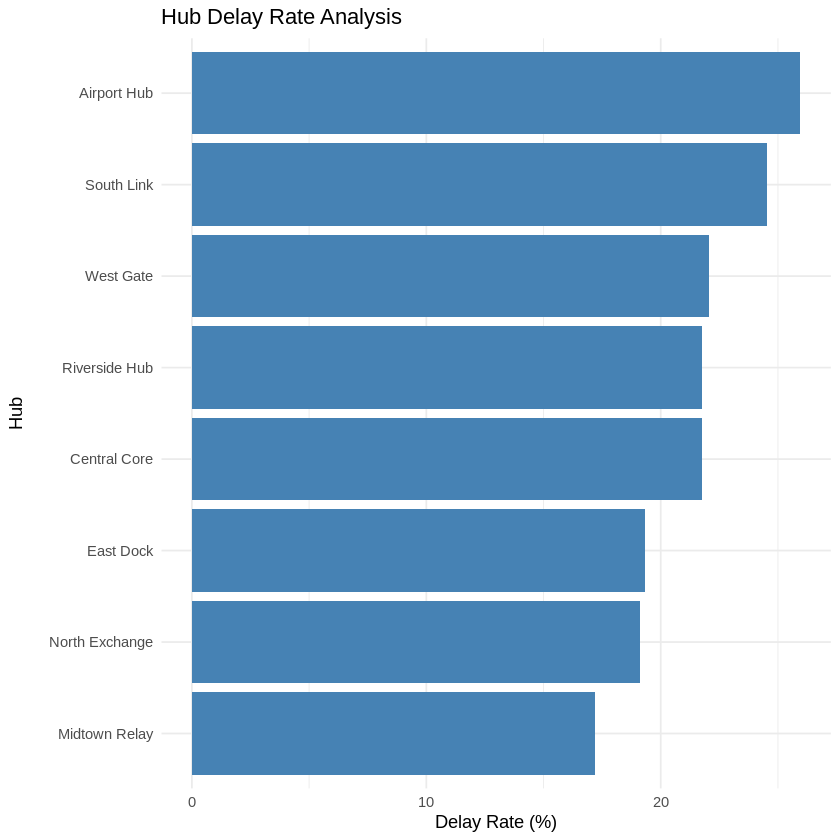

In [ ]:
# ==========================================
# VISUALISATION
# HUB DELAY RATE
# ==========================================

ggplot(
  high_delay_hubs,
  aes(
    x = reorder(hub_name, delay_rate_percentage),
    y = delay_rate_percentage
  )
) +
  geom_bar(stat = "identity", fill = "steelblue") +
  coord_flip() +
  labs(
    title = "Hub Delay Rate Analysis",
    x = "Hub",
    y = "Delay Rate (%)"
  ) +
  theme_minimal()

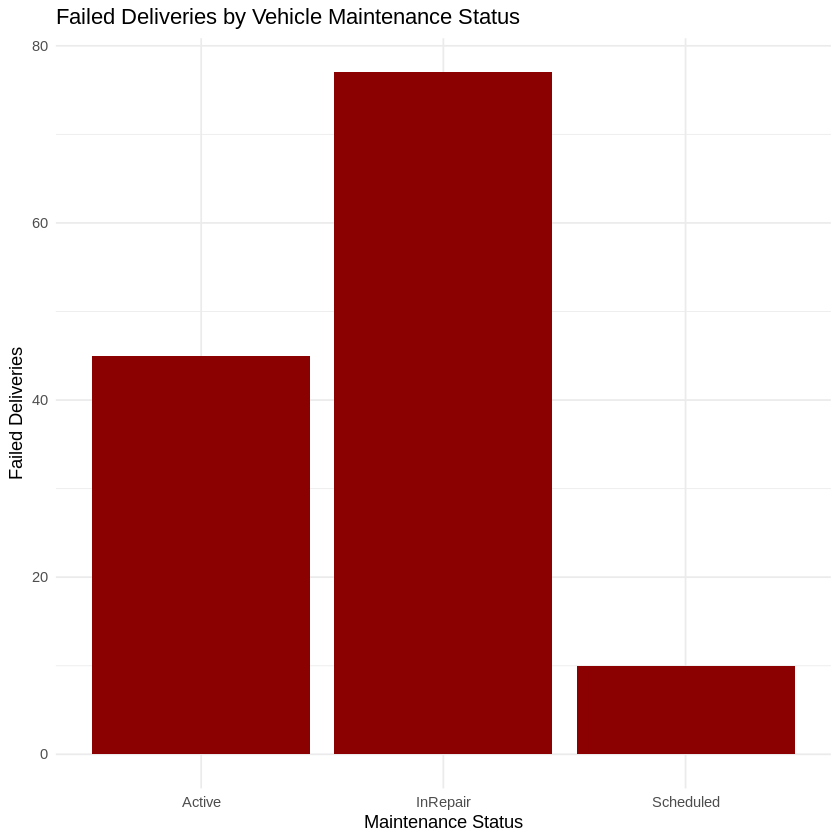

In [ ]:
# ==========================================
# VEHICLE MAINTENANCE VISUAL
# ==========================================

ggplot(
  vehicle_analysis,
  aes(
    x = maintenance_status,
    y = failed_deliveries
  )
) +
  geom_bar(stat = "identity", fill = "darkred") +
  labs(
    title = "Failed Deliveries by Vehicle Maintenance Status",
    x = "Maintenance Status",
    y = "Failed Deliveries"
  ) +
  theme_minimal()

In [ ]:
# ==========================================
# EXPORT CLEANED DATASETS
# ==========================================

write.csv(deliveries, "cleaned_deliveries.csv", row.names = FALSE)
write.csv(complaints, "cleaned_complaints.csv", row.names = FALSE)
write.csv(incidents, "cleaned_incidents.csv", row.names = FALSE)

cat("Cleaned datasets exported successfully.\n")

Cleaned datasets exported successfully.
